**QUESTION 1**

A piece of paper is 0.1 mm thick. However, paper thickness varies: tissue paper is
around 0.05 mm, cardstock around 0.3 mm.
a. How many folds does it take to exceed the height of Mount Everest at 8,848 m?
b. How does your answer change across different paper types mentioned?
c. At what initial thickness would exactly 20 folds be enough?
d. Plot the number of folds required as a function of paper thickness, mark all 3
thickness and their folds, and explain what the shape of that curves tells you.

In [143]:
import math

paper_measurement = 0.1 # thickness of the paper in millimeters
height_Mt_Everest = 8848 # height of Mt Everest in meteres

#function that converts millimeters to meters
def mmToMeter(paper_measurement):
  return paper_measurement /1000

# function that calculates the number of folds that exceeds the height of Mt Everest
def calculateFolds(paper_measurement):
  paper_measurement = mmToMeter(paper_measurement)
  #I am using math.ceil to round up because I actually need the fold to exceed the height of Mt Everest
  numberOfFolds= math.ceil(round(math.log2(height_Mt_Everest/paper_measurement), 3))
  return numberOfFolds
print(calculateFolds(paper_measurement))


27


It takes 26.4 folds to get to the exact height of Mount Everest. Hence to exceed the height of Mount Everest, it needs

**27 folds**.

b. How does your answer change across different paper types mentioned?

In [144]:
"""
I will now calculate the number of folds that is required to exceed the height of Mt Everest
for the tissue paper and cardstock by using the calculateFolds function
"""
tissue_paper_thickness = 0.05 #0.05mm
cardstock_thickness = 0.3 #0.3mm
print(f"Number of folds required by tissue paper: {calculateFolds(tissue_paper_thickness)}")
print(f"Number of folds required by cardstock: {calculateFolds(cardstock_thickness)}")

Number of folds required by tissue paper: 28
Number of folds required by cardstock: 25


c. At what initial thickness would exactly 20 folds be enough?

In [145]:
#function to calculate the thickness for 20 folds of paper to exceed Mount Everest
num_of_folds = 20

def calculateThickness(num_of_folds, height_Mt_Everest):
  return round((height_Mt_Everest * 1000)/(2**num_of_folds),2)

print(f"{calculateThickness(num_of_folds, height_Mt_Everest)}mm")

8.44mm


d. Plot the number of folds required as a function of paper thickness, mark all 3 thickness and their folds, and explain what the shape of that curve tells you.

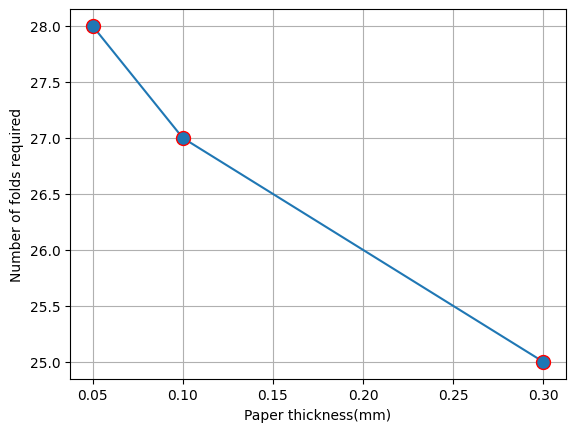

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

xpoints = np.array([tissue_paper_thickness, paper_measurement, cardstock_thickness])
ypoints = np.array([calculateFolds(tissue_paper_thickness), calculateFolds(paper_measurement), calculateFolds(cardstock_thickness)])

plt.plot(xpoints, ypoints, marker = 'o', mec = 'r', ms = 10)
plt.xlabel("Paper thickness(mm)")
plt.ylabel("Number of folds required")
plt.grid()
plt.show()


The shape of the curve above tells me that there is an inverse relationship between the paper thickness and the number of folds required to exceed the height of Mount Everest. As the thicknesss of paper increases further, it will require less number of folds to exceed the height of Mount Everest.

**QUESTION 2**

The volume of water in a reservoir follows v(t) = v(0)exp(−at), where a = 0.05 per day.

*a.* Calculate the time for the volume to drop below 50% and 10% of its initial
value. Show your working.

In [5]:
import math
#function to calculate the time(number of days) for the volume to drop below x% of its initial value
time_taken, volume_of_water = 0, 1 #v0 and t
max_drop = 0.5
a = 0.05
time_increase = 0.01

def calculateTime(time_taken, volume_of_water, max_drop, a, time_increase):
  while volume_of_water >= max_drop:
    volume_of_water = volume_of_water * math.exp(-a*time_increase)
    time_taken += time_increase

  return(round(time_taken,2))

print(f"Time taken to drop below 50%: {calculateTime(time_taken, volume_of_water, max_drop, a, time_increase)}")
print(f"Time taken to drop below 10%: {calculateTime(time_taken, volume_of_water, 0.1, a, time_increase)}")

Time taken to drop below 50%: 13.87
Time taken to drop below 10%: 46.06


**b.** The exponential model implies the reservoir never reaches zero. Choose a
volume threshold at which you consider the reservoir effectively empty, justify
your choice, and calculate the corresponding time.

I select a volume threshold of 5% of the original capacity because at 5%, the water pressure would have dropped significantly and unable to supply any significant amount.

In [6]:
#time taken to drop below threshold that I consider as relatively empty
print(f"Time taken to drop below 5%: {calculateTime(time_taken, volume_of_water, 0.05, a, time_increase)}")

Time taken to drop below 5%: 59.92


**c**. In practice, a varies with climate, season, and human activity. Repeat your calculations for a = 0.15 per day, plot both decay curves on the same graph, and mark the three threshold points on each. What does the diff erence between the two curves tell you about the reliability of predictions based on a single fixed value of a?

In [7]:
# to recompute the time, I will only change a to 0.15
a = 0.15

print(f"Time taken to drop below 50% at a = 0.15: {calculateTime(time_taken, volume_of_water, max_drop, a, time_increase)}")
print(f"Time taken to drop below 10% at a = 0.15: {calculateTime(time_taken, volume_of_water, 0.1, a, time_increase)}")

#my threshold of 5%
print(f"Time taken to drop below 5% at a = 0.15: {calculateTime(time_taken, volume_of_water, 0.05, a, time_increase)}")

Time taken to drop below 50% at a = 0.15: 4.63
Time taken to drop below 10% at a = 0.15: 15.36
Time taken to drop below 5% at a = 0.15: 19.98


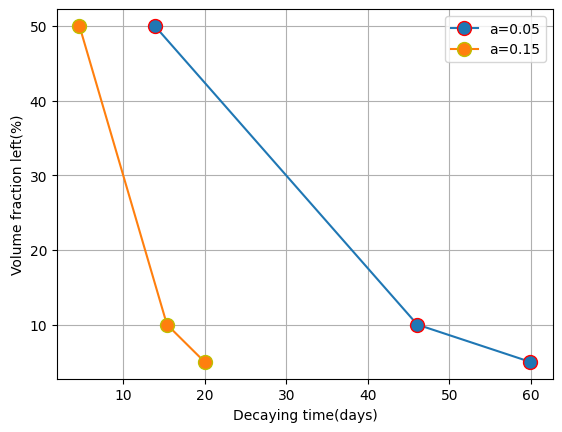

In [8]:
x1points = np.array([calculateTime(time_taken, volume_of_water, max_drop, 0.05, time_increase),
                    calculateTime(time_taken, volume_of_water, 0.1, 0.05, time_increase),
                    calculateTime(time_taken, volume_of_water, 0.05, 0.05, time_increase)])
y1points = np.array([50, 10, 5])

plt.plot(x1points, y1points, marker = 'o', mec = 'r', ms = 10, label = 'a=0.05')

x2points = np.array([calculateTime(time_taken, volume_of_water, max_drop, 0.15, time_increase),
                    calculateTime(time_taken, volume_of_water, 0.1, 0.15, time_increase),
                    calculateTime(time_taken, volume_of_water, 0.05, 0.15, time_increase)])
y2points = np.array([50, 10, 5])

plt.plot(x2points, y2points, marker = 'o', mec = 'y', ms = 10, label = 'a=0.15')
plt.xlabel("Decaying time(days)")
plt.ylabel("Volume fraction left(%)")
plt.legend()
plt.grid()
plt.show()

The difference between the two curves tells me that as the value of *a* **increases**, it **reduces** the *decaying time*.

**QUESTION 3**

You deposit $500 in a bank account offering an annualised interest rate of 5%, compounded annually.

a. Calculate the balance after 1, 2, 3, 4, and 5 years.

In [9]:
#I know that to calculate the balance, A, for interest compounded annually(n=1) is A=P(1+r)^t
#the function for calculating the balance is below

def calculateBalance(P,r,t):
  return math.ceil(P*(1+r)**t)

P, r_bank = 500, 0.05 #the constant values for P and r
#to calculate the balance from 1 to 5 years, we can use a for loop
for t in range(1, 6):
  print(f"Balance after {t} year{"s" if t>1 else ""} is ${calculateBalance(P, r_bank, t)}")


Balance after 1 year is $525
Balance after 2 years is $552
Balance after 3 years is $579
Balance after 4 years is $608
Balance after 5 years is $639


b. Look up the current savings rate offered by two real banks operating in Rwanda or East Africa. Using the same 500 deposit, calculate the five-year balance at each bank's rate and compare it to the 5% scenario. At what deposit amount would the difrerence between the 5% rate and you best local bank rate exceed $100?

GTBank offers a 4% savings rate.
Hence r = 0.04

In [10]:
print(f"BALANCES WHEN SAVING WITH GT BANK")
r = 0.04 #interest rate of Gt Bank
for t in range(1, 6):
  print(f"Balance after {t} year{"s" if t>1 else ""} is ${calculateBalance(P, r, t)}")

BALANCES WHEN SAVING WITH GT BANK
Balance after 1 year is $520
Balance after 2 years is $541
Balance after 3 years is $563
Balance after 4 years is $585
Balance after 5 years is $609


The balances from GT Bank(4%) are lower than the initial bank because the savings rate of GT Bank is lower than the savings rate of the initial bank(5%).

KCB Kenya Limited offers a 7% savings rate via the Simba savings Account:


In [11]:
print(f"BALANCE WHEN SAVING WITH KCB Kenya")
r_kcb = 0.07 #interest rate of KCB Kenya
t = 5 #calculating for the five-year plan
print(f"Balance after {t} years is ${calculateBalance(P, r_kcb, t)}")

BALANCE WHEN SAVING WITH KCB Kenya
Balance after 5 years is $702


The balance from KCB Kenya after 5 years is higher than the initial bank because the savings rate of KCB Kenya(7%) is higher than the savings rate of the initial bank(5%).

In [12]:
#to check the deposit at which the difference between the 5% bank and KCB Kenya (7%) be greater than 100
t = 5
diff = 0
while diff <=100:
  diff = calculateBalance(P, r_kcb, t) - calculateBalance(P, r_bank, t)
  P += 0.01
print(math.ceil(P))

793


**QUESTION 4**

You want to buy a car worth $20,000, tax-inclusive. A financial institution offers a loan with a monthly interest rate of 5%.

a. Calculate the monthly payment required to clear the debt in 1, 2, and 3 years. Round to the nearest dollar.

In [13]:
#I know that to calculate the monthly payments A, for paying of debts A=P*r*(1+r)^t
#the function for calculating the balance is below
def calculatePaymentAmount(P,r,n):
  return math.ceil(P * (r * (1 + r) ** n) / (((1 + r) ** n) - 1))

P, r_repay = 20000, 0.05 #the constant values for P and r
#to calculate the balance for 1 to 3 years, we can use a for loop
for n in range(12, 37, 12):
  print(f"Monthly payment for debt to be cleared in {int(n/12)} year{'s' if n/12 > 1 else ''}: ${calculatePaymentAmount(P, r_repay, n)}")

Monthly payment for debt to be cleared in 1 year: $2257
Monthly payment for debt to be cleared in 2 years: $1450
Monthly payment for debt to be cleared in 3 years: $1209


b. Rwanda is encouraging the adoption of electric vehicles by removing the 15% import tax. If you purchase an electric car of equivalent value, the effective car price is reduced by 15%. Recalculate the monthly payment for one, two, and three years under this new price. How much will you save if you pay in one, two, and three years compared to the original loan?

In [14]:
#Monthly payment after removal of 15% import tax

#a 15% reduction in the price of the car
# I am defining a new variable because I do not want P to be modified as it would be used later
new_p = P - (0.15*P)
for n in range(12, 37, 12):
  print(f"Monthly payment for debt to be cleared in {int(n/12)} year{'s' if n/12 > 1 else ''} under new price: ${calculatePaymentAmount(new_p, r_repay, n)}")

Monthly payment for debt to be cleared in 1 year under new price: $1919
Monthly payment for debt to be cleared in 2 years under new price: $1233
Monthly payment for debt to be cleared in 3 years under new price: $1028


In [15]:
#calculating the amount saved is basically the monthly payment at old price - monthly payment at new price * number of months
for n in range(12, 37, 12):
  print(f"Amount saved for payment by paying installmentally in {int(n/12)} year{'s' if n/12 > 1 else ''} under new price: ${((
  calculatePaymentAmount(P, r_repay, n) - calculatePaymentAmount(new_p, r_repay, n)) * n)} ")

Amount saved for payment by paying installmentally in 1 year under new price: $4056 
Amount saved for payment by paying installmentally in 2 years under new price: $5208 
Amount saved for payment by paying installmentally in 3 years under new price: $6516 


**QUESTION 5**

You are about to set up a new business in Kigali and will invest $100,000.

On day one, you expect to have 40 customers, and the number of customers will  grow at a rate of 0.5% per day. Each customer generates a profit of $5 per day

a. How many days will it take to repay your initial investment based on cumulative profits?

In [16]:
num_of_customers = 40 #number of customers
I = 100000 #investment
cumulative_profit = 0
daily_profits = [] #keep track of the number of days and accumulated profit for each day
day_count = 0
growth_customers = 0.005 #growth of customers
profit_share = 1 #in the first scenario, I take all 100% of the profit

def calculate_days(num_of_customers, I, cumulative_profit, daily_profits, day_count, growth_customers, profit_share):
  while cumulative_profit < I:
    cumulative_profit += round(num_of_customers * 5 * profit_share, 2) #increase the cumulative profit everyday
    day_count += 1
    daily_profits.append([day_count, cumulative_profit])
    num_of_customers += num_of_customers * growth_customers #customers increase by 0.5%

  return day_count

print(calculate_days(num_of_customers, I, cumulative_profit, daily_profits, day_count, growth_customers, profit_share))




252


**B.** Plot the cumulative profits per day, mark the initial investment as a horizontal line, and mark the breakeven day clearly on the graph.

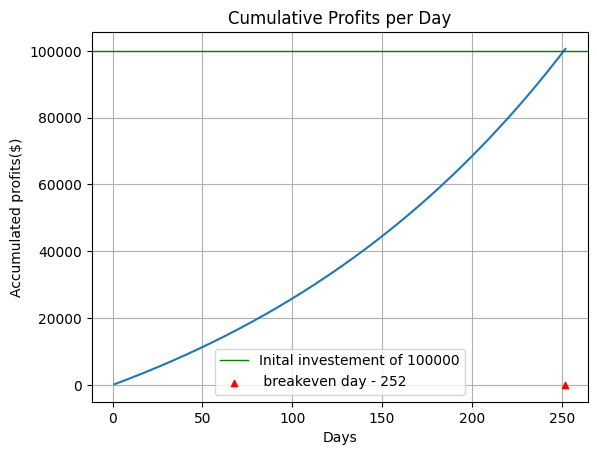

In [17]:
#build the array for the x and y axis respectively
days= [day[0] for day in daily_profits]
profit = [day[1] for day in daily_profits]

xpoints = np.array(days)
ypoints = np.array(profit)

plt.plot(xpoints, ypoints, mec = 'y')
plt.title("Cumulative Profits per Day")
plt.xlabel("Days")
plt.ylabel("Accumulated profits($)")

#breakeven day(252)
plt.axhline(
    y=100000,
    color='g',
    linestyle='-',
    linewidth=1,
    label='Inital investement of 100000'
)

#breakeven day(252)
plt.scatter(
    x=252,
    y=0,
    color='r',
    marker='^',
    s=20,
    zorder=5,
    label = " breakeven day - 252"
)

plt.grid()
plt.legend(loc='lower center')
plt.show()

It will take **252** days to repay the initial investment based on cumulative profits.

C. Bank of Kigali offers to double your initial investment to $200,000 in exchange for a 50% share of daily profits. As an entrepreneur, would you take the deal if the customers grow at 0.7% due to the deal?

In [18]:
#we only need to change the values of 3 variables
I = 200000
growth_customers = 0.007
profit_share = 0.5 # in this case, I take 50% of the profit

#the rest remain the same
num_of_customers = 40 #number of customers
cumulative_profit = 0
daily_profits = [] #keep track of the number of days and accumulated profit for each day
day_count = 0
print(calculate_days(num_of_customers, I, cumulative_profit, daily_profits, day_count, growth_customers, profit_share))

389


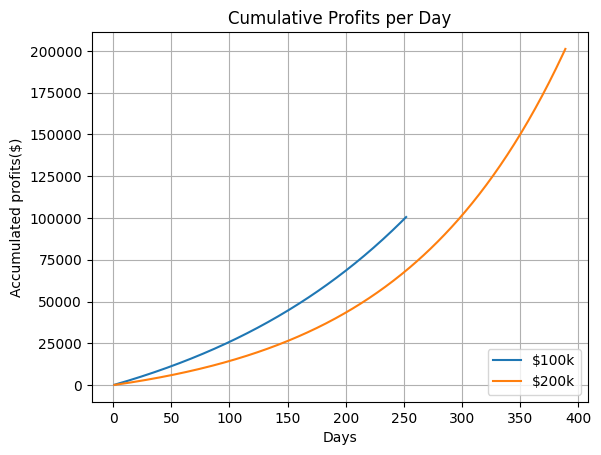

In [19]:
xpoints = np.array(days)
ypoints = np.array(profit)

plt.plot(xpoints, ypoints, mec = 'y', label='$100k')

#build the array for the x and y axis respectively
days2= [day[0] for day in daily_profits]
profit2 = [day[1] for day in daily_profits]

x2points = np.array(days2)
y2points = np.array(profit2)
plt.plot(x2points, y2points, mec = 'y', label='$200k')
plt.title("Cumulative Profits per Day")
plt.xlabel("Days")
plt.ylabel("Accumulated profits($)")
plt.grid()
plt.legend(loc='lower right')
plt.show()

**QUESTION 6**

In [146]:
import pandas as pd

df_ebola = pd.read_csv('drc_zones_timeseries-zonal.csv')
#clean the data of all occurence of "Haut-UÃ©lÃ©"
df_ebola["Province"] = df_ebola["Province"].replace("Haut-UÃ©lÃ©", "Haut-Uele")
print(df_ebola.head())

        Date Health Zone Province  Confirmed Cases  Confirmed Deaths
0  5/14/2026   Mongbwalu    Ituri                0               NaN
1  5/15/2026       Bunia    Ituri                0               NaN
2  5/15/2026   Mongbwalu    Ituri                0               NaN
3  5/15/2026    Rwampara    Ituri               13               NaN
4  5/18/2026       Bunia    Ituri                6               NaN


In [147]:
# group all the provinces together in a dataframe, obtain their sum, check if it is greater than 0 and count the number of rows
provinces_df = df_ebola.groupby("Province")

provinces_df = provinces_df["Confirmed Cases"].sum()

provinces_df = provinces_df[provinces_df > 0]

print(provinces_df.count())

5


There are **5** DRC provinces affected.

In [148]:
#aggregate the data into a single national daily series and fill up missing dates
nationaldaily_df = (df_ebola.groupby("Date").sum()[["Confirmed Cases", "Confirmed Deaths"]])

print(nationaldaily_df.head())

           Confirmed Cases  Confirmed Deaths
Date                                        
5/14/2026                0               0.0
5/15/2026               13               0.0
5/18/2026               33               0.0
5/19/2026               51               0.0
5/20/2026               57               0.0


In [58]:
#get the cumulative cases and deaths by getting the last value in the series

print(f'The cumulative number of cases is: {nationaldaily_df["Confirmed Cases"].iloc[-1]}')
print(f'The cumulative number of deaths is: {nationaldaily_df["Confirmed Deaths"].iloc[-1]}')

The cumulative number of cases is: 3973
The cumulative number of deaths is: 1801.0


In [104]:

#to calculate the  number of missing dates

df_ebola["Date"] = pd.to_datetime(df_ebola["Date"])
print(len(pd.date_range(
  start="2026-05-14", end="2026-08-04").difference(df_ebola["Date"])))


11


In [142]:
nationaldaily_df = nationaldaily_df.asfreq('D')
nationaldaily_df = nationaldaily_df.interpolate(method='linear')

#I discovered that the Confirmed Deaths for 2026-06-16 did not interpolate, I am still trying to find why, however,
# I interpolated it manually.
nationaldaily_df.loc['2026-06-16', "Confirmed Deaths"] = (
    nationaldaily_df.loc['2026-06-15', "Confirmed Deaths"] +
    nationaldaily_df.loc['2026-06-17', "Confirmed Deaths"]
) / 2
print(nationaldaily_df.head())

            Confirmed Cases  Confirmed Deaths
Date                                         
2026-05-14         0.000000               0.0
2026-05-15        13.000000               0.0
2026-05-16        19.666667               0.0
2026-05-17        26.333333               0.0
2026-05-18        33.000000               0.0


In [111]:
#filter the index when cumulative cases is greater than 100
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 100].index)

DatetimeIndex(['2026-05-24', '2026-05-26', '2026-05-27', '2026-05-28',
               '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01',
               '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05',
               '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13',
               '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17',
               '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29',
               '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03',
               '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07',
               '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11',
               '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19',
      

In [112]:
#filter the index when cumulative cases is greater than 500
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 500].index)

DatetimeIndex(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
               '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15',
               '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19',
               '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27',
               '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05',
               '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09',
               '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13',
               '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17',
               '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25',
               '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29',
               '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02',
      

In [113]:
#filter the index when cumulative cases is greater than 1000
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 1000].index)

DatetimeIndex(['2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24',
               '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28',
               '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02',
               '2026-07-03', '2026-07-04', '2026-07-05', '2026-07-06',
               '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10',
               '2026-07-11', '2026-07-12', '2026-07-13', '2026-07-14',
               '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-18',
               '2026-07-19', '2026-07-20', '2026-07-21', '2026-07-22',
               '2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26',
               '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30',
               '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03',
               '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [114]:
#filter the index when cumulative cases is greater than 2000
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 2000].index)

DatetimeIndex(['2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17',
               '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25',
               '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29',
               '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02',
               '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [115]:
#filter the index when cumulative cases is greater than 3500
print(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 3500].index)

DatetimeIndex(['2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01',
               '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


**PLOT THE CUMULATIVE CASES AGAINST THE DATES**

In [68]:
#filter the dates where cumulative cases is greater than 100
x4points = (list(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 100].index.strftime('%Y-%m-%d')))
print(x4points)


['2026-05-24', '2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31', '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03', '2026

In [69]:
#get the confirmed cases when cumulative cases is greater than 100
y4points = (list(nationaldaily_df[nationaldaily_df["Confirmed Cases"] > 100]["Confirmed Cases"]))
print(y4points)

[101.0, 111.0, 119.0, 243.0, 243.0, 243.0, 246.5, 250.0, 269.0, 281.0, 356.0, 394.0, 421.0, 456.0, 502.0, 541.0, 582.0, 595.0, 641.5, 688.0, 714.0, 776.0, 781.0, 880.0, 916.0, 939.0, 986.0, 1031.0, 1077.0, 1098.0, 1138.0, 1186.0, 1218.5, 1251.0, 1283.5, 1316.0, 1389.0, 1443.0, 1485.0, 1511.0, 1544.0, 1607.0, 1691.0, 1742.0, 1772.0, 1813.0, 1861.0, 1909.0, 1951.5, 1994.0, 2056.0, 2107.0, 2178.5, 2250.0, 2327.0, 2406.0, 2456.0, 2519.0, 2905.0, 2973.0, 3075.0, 3200.0, 3262.0, 3360.0, 3441.6666666666665, 3523.3333333333335, 3605.0, 3674.0, 3748.0, 3802.0, 3874.0, 3973.0]


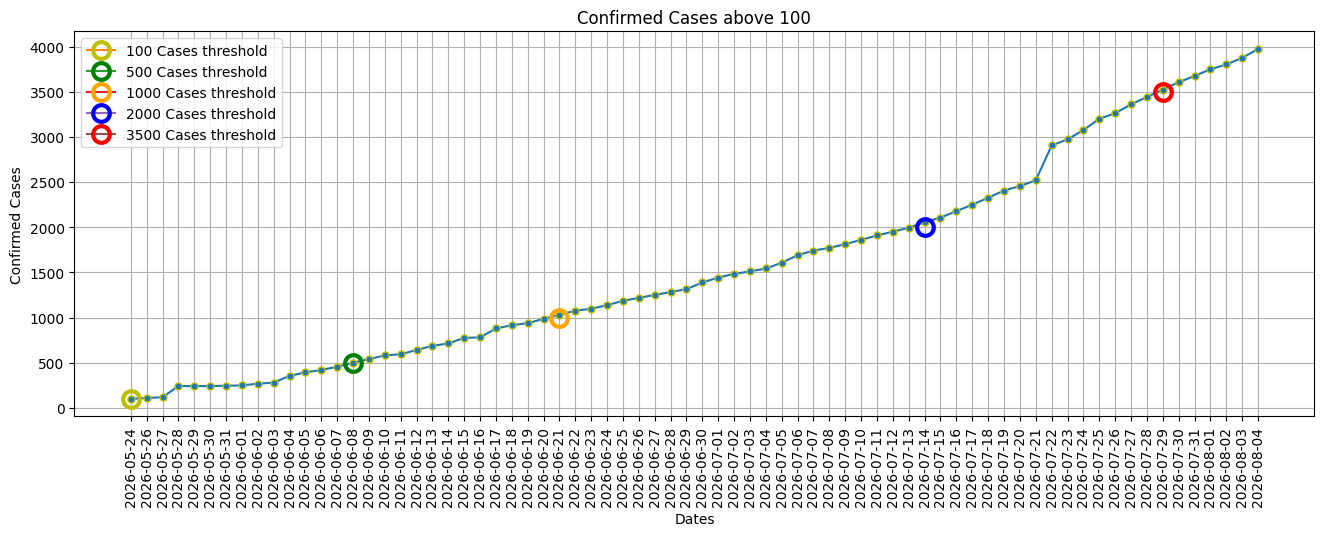

In [139]:
# the graph needs to be made larger and the dates has to be rotated for proper viewing
plt.figure(figsize=(16, 5))
plt.xticks(rotation=90)

plt.plot(x4points, y4points, marker = 'o', mec = 'y', ms = 5)
plt.xlabel("Dates")
plt.ylabel("Confirmed Cases")
plt.title("Confirmed Cases above 100")


# thresholds of 100, 500, 1000, 2000 and 3500 confirmed cases
plt.plot('2026-05-24', 100, marker='o', ms=12, mfc='none', mec='y', mew=3, label='100 Cases threshold')
plt.plot('2026-06-08', 500, marker='o', ms=12, mfc='none', mec='g', mew=3, label='500 Cases threshold')
plt.plot('2026-06-21', 1000, marker='o', ms=12, mfc='none', mec='orange', mew=3, label='1000 Cases threshold')
plt.plot('2026-07-14', 2000, marker='o', ms=12, mfc='none', mec='b', mew=3, label='2000 Cases threshold')
plt.plot('2026-07-29', 3500, marker='o', ms=12, mfc='none', mec='r', mew=3, label='3500 Cases threshold')

plt.legend()
plt.grid()
plt.show()

In [116]:
#filter the index when cumulative deaths is greater than 50
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 50].index)

DatetimeIndex(['2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05',
               '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13',
               '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17',
               '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29',
               '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03',
               '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07',
               '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11',
               '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19',
               '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23',
               '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27',
      

In [117]:
#filter the index when cumulative deaths is greater than 100
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 100].index)

DatetimeIndex(['2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11',
               '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15',
               '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19',
               '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27',
               '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01',
               '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05',
               '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09',
               '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13',
               '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17',
               '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21',
               '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25',
               '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29',
               '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02',
      

In [118]:
#filter the index when cumulative deaths is greater than 500
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 500].index)

DatetimeIndex(['2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07',
               '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11',
               '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15',
               '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19',
               '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23',
               '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27',
               '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31',
               '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [119]:
#filter the index when cumulative deaths is greater than 1000
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 1000].index)

DatetimeIndex(['2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24',
               '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28',
               '2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01',
               '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


In [120]:
#filter the index when cumulative deaths is greater than 1500
print(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 1500].index)

DatetimeIndex(['2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31',
               '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04'],
              dtype='datetime64[ns]', name='Date', freq='D')


**PLOT THE CUMULATIVE DEATHS AGAINST THE DATES**

In [121]:
#filter the dates where cumulative deaths is greater than 50
x5points = (list(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 50].index.strftime('%Y-%m-%d')))
print(x5points)


#get the confirmed deaths when cumulative deaths is greater than 50
y5points = (list(nationaldaily_df[nationaldaily_df["Confirmed Deaths"] > 50]["Confirmed Deaths"]))
print(y5points)

['2026-06-02', '2026-06-03', '2026-06-04', '2026-06-05', '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09', '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13', '2026-06-14', '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-20', '2026-06-21', '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-27', '2026-06-28', '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-03', '2026-07-04', '2026-07-05', '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-11', '2026-07-12', '2026-07-13', '2026-07-14', '2026-07-15', '2026-07-16', '2026-07-17', '2026-07-18', '2026-07-19', '2026-07-20', '2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-25', '2026-07-26', '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03', '2026-08-04']
[52.0, 53.0, 72.0, 76.0, 81.0, 91.0, 105.0, 117.0, 126.0, 132.0, 151.5, 171.0, 182.0, 186.0, 209.5, 233

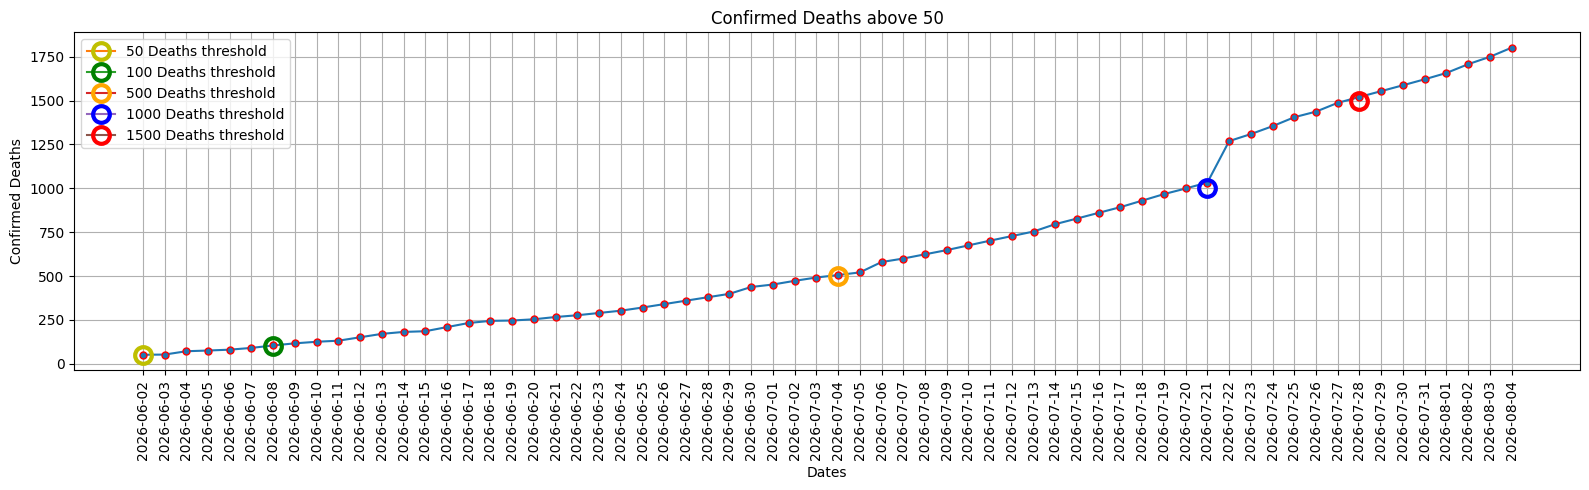

In [149]:
import matplotlib.pyplot as plt

# the graph needs to be made larger and the dates has to be rotated for proper viewing
plt.figure(figsize=(16, 5))
plt.xticks(rotation=90)

plt.plot(x5points, y5points, marker = 'o', mec = 'r', ms = 5)
plt.xlabel("Dates")
plt.ylabel("Confirmed Deaths")
plt.title("Confirmed Deaths above 50")

# thresholds of 50, 100, 500, 1000 and 1500 confirmed deaths
plt.plot('2026-06-02', 50, marker='o', ms=12, mfc='none', mec='y', mew=3, label='50 Deaths threshold')
plt.plot('2026-06-08', 100, marker='o', ms=12, mfc='none', mec='g', mew=3, label='100 Deaths threshold')
plt.plot('2026-07-04', 500, marker='o', ms=12, mfc='none', mec='orange', mew=3, label='500 Deaths threshold')
plt.plot('2026-07-21', 1000, marker='o', ms=12, mfc='none', mec='b', mew=3, label='1000 Deaths threshold')
plt.plot('2026-07-28', 1500, marker='o', ms=12, mfc='none', mec='r', mew=3, label='1500 Deaths threshold')

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


**e.** Plot cumulative deaths against cumulative cases, and discuss the case fatality rate among confirmed cases.

In [124]:
# put cumululative deaths into an array
y6points = list(nationaldaily_df["Confirmed Deaths"])
print(y6points)

#put cumulative cases into an array
x6points = list(nationaldaily_df["Confirmed Cases"])
print(x6points)


[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 43.0, 42.0, 42.0, 46.0, 50.0, 52.0, 53.0, 72.0, 76.0, 81.0, 91.0, 105.0, 117.0, 126.0, 132.0, 151.5, 171.0, 182.0, 186.0, 209.5, 233.0, 245.0, 247.0, 254.0, 267.0, 277.0, 290.0, 303.0, 321.0, 340.5, 360.0, 379.5, 399.0, 438.0, 452.0, 473.0, 492.0, 506.0, 521.0, 580.0, 600.0, 624.0, 648.0, 675.0, 702.0, 728.0, 754.0, 796.0, 828.0, 860.5, 893.0, 930.0, 967.0, 999.0, 1033.0, 1269.0, 1309.0, 1354.0, 1405.0, 1437.0, 1487.0, 1520.3333333333333, 1553.6666666666667, 1587.0, 1621.0, 1657.0, 1707.0, 1749.0, 1801.0]
[0.0, 13.0, 19.666666666666668, 26.333333333333336, 33.0, 51.0, 57.0, 79.0, 83.0, 95.0, 101.0, 100.0, 111.0, 119.0, 243.0, 243.0, 243.0, 246.5, 250.0, 269.0, 281.0, 356.0, 394.0, 421.0, 456.0, 502.0, 541.0, 582.0, 595.0, 641.5, 688.0, 714.0, 776.0, 781.0, 880.0, 916.0, 939.0, 986.0, 1031.0, 1077.0, 1098.0, 1138.0, 1186.0, 1218.5, 1251.0, 1283.5, 1316.0, 1389.0, 1443.0, 1485.0, 1511.0, 1544.0, 1607.0, 1691.0, 1742.0

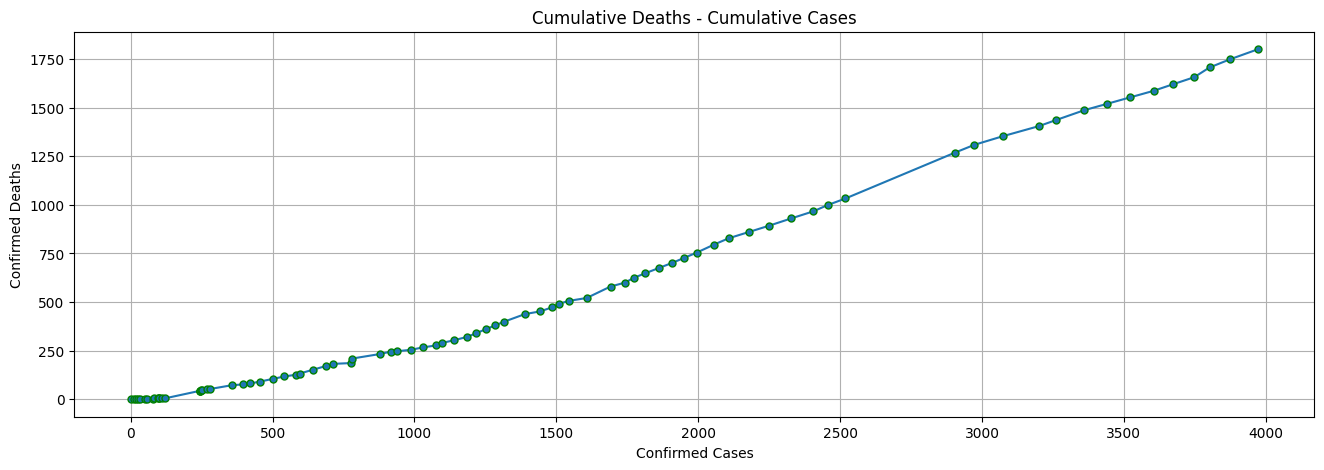

In [150]:
plt.figure(figsize=(16, 5))

plt.plot(x6points, y6points, marker = 'o', mec = 'g', ms = 5)
plt.xlabel("Confirmed Cases")
plt.ylabel("Confirmed Deaths")
plt.title("Cumulative Deaths - Cumulative Cases")


plt.grid()
plt.show()

**QUESTION 7

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


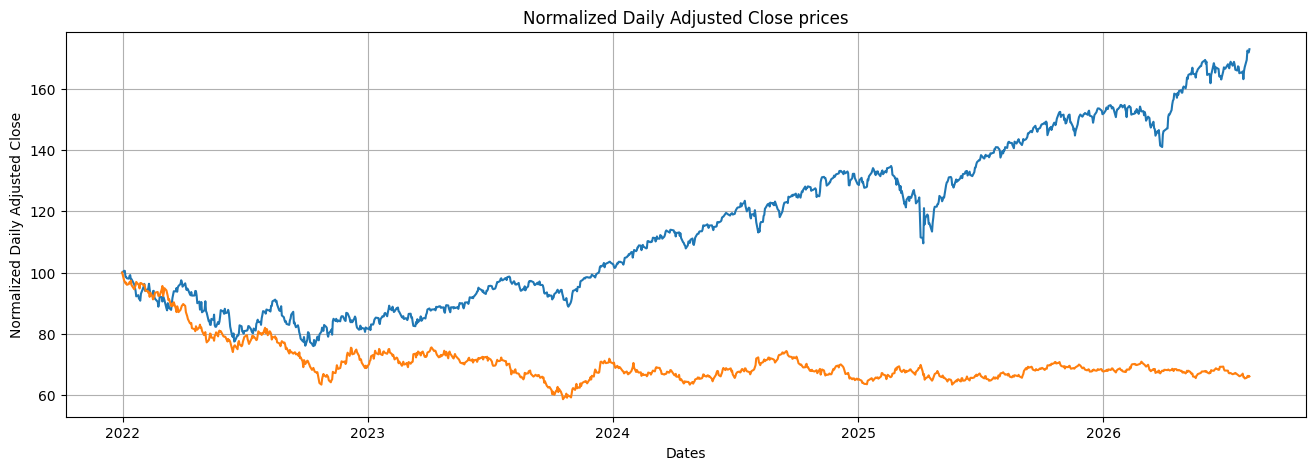

In [151]:
import yfinance as yf
import pandas as pd

#SPY
spy_df = yf.download("SPY", start="2021-12-31", end="2026-08-10", auto_adjust=False)
spy_df_adjCl=spy_df.iloc[:,[0]]

#normalization
base_spy = spy_df.iloc[0,0]
normalized_spy = (spy_df_adjCl/base_spy) * 100

#TLT
tlt_df = yf.download("TLT", start="2021-12-31", end="2026-08-10", auto_adjust=False)
tlt_df_adjCl=tlt_df.iloc[:,[0]]

#normalization
base_tlt = tlt_df.iloc[0,0]
normalized_tlt = (tlt_df_adjCl/base_tlt) * 100

#eliminate multiindex wrappers:
normalized_spy.columns = ['Normalized_adjCl']
normalized_tlt.columns = ['Normalized_adjCl']

#get the dates for SPY to build up the array for plotting
x7points = normalized_spy.index

#get the prices for SPY
y7points = list(normalized_spy["Normalized_adjCl"])

#get the dates for SPY to build up the array for plotting
x8points = normalized_tlt.index

#get the prices for SPY
y8points = list(normalized_tlt["Normalized_adjCl"])

plt.figure(figsize=(16, 5))


plt.plot(x7points, y7points)
plt.plot(x8points, y8points)
plt.xlabel("Dates")
plt.ylabel("Normalized Daily Adjusted Close")
plt.title("Normalized Daily Adjusted Close prices")

plt.grid()
plt.show()

In [152]:
# obtain the 6 month window
yearly_trading_days = 252
window_6month = yearly_trading_days//2

#we need to constantly update the start and end date
start_date = None
end_date = None

##initialize the percentage change to 0
spy_percent_change = 0.0
tlt_percent_change = 0.0

# Use two-pointers to obtain the prices at i and i + window_6month:
for i in range(len(y7points) - window_6month):

    # the left pointer in both SPY AND TLT
    spy_start_price = y7points[i]
    tlt_start_price = y8points[i]

    # the right pointer in both of them
    spy_end_price = y7points[i + window_6month]
    tlt_end_price = y8points[i + window_6month]

    # the condition is true for a six-month window where both series ended lower than they started
    if (spy_end_price < spy_start_price) and (tlt_end_price < tlt_start_price):

        #extract the calendar dates
        start_date = x7points[i].strftime('%Y-%m-%d')
        end_date = x7points[i + window_6month].strftime('%Y-%m-%d')

        # Calculate percentage changes
        spy_percent_change = ((spy_end_price - spy_start_price) / spy_start_price) * 100
        tlt_percent_change = ((tlt_end_price - tlt_start_price) / tlt_start_price) * 100

        break

print(f"The Start Date is: {start_date}")
print(f"The End Date is: {end_date}")
print(f"SPY Percentage Change between {start_date} and {end_date}: {round(spy_percent_change, 2)}%")
print(f"TLT Percentage Change between {start_date} and {end_date}: {round(tlt_percent_change, 2)}%")





The Start Date is: 2021-12-31
The End Date is: 2022-07-05
SPY Percentage Change between 2021-12-31 and 2022-07-05: -18.98%
TLT Percentage Change between 2021-12-31 and 2022-07-05: -20.46%


**b.** Compute the 60-day rolling correlation between SPY and TLT over time. Plot the results and identify some dates where the correlation is positive. Discuss why the correlation values might be positive or negative.

            SPY_Daily_Return  TLT_Daily_Return  Rolling_Correlation
Date                                                               
2022-01-03          0.005790         -0.026250                  NaN
2022-01-04         -0.000335         -0.004158                  NaN
2022-01-05         -0.019202         -0.005428                  NaN
2022-01-06         -0.000939          0.002589                  NaN
2022-01-07         -0.003954         -0.007188                  NaN
...                      ...               ...                  ...
2026-08-03          0.014243          0.003296             0.392081
2026-08-04          0.018029          0.007665             0.414980
2026-08-05         -0.001997          0.002173             0.404203
2026-08-06         -0.001598         -0.005783             0.411155
2026-08-07          0.006115          0.002908             0.413984

[1153 rows x 3 columns]


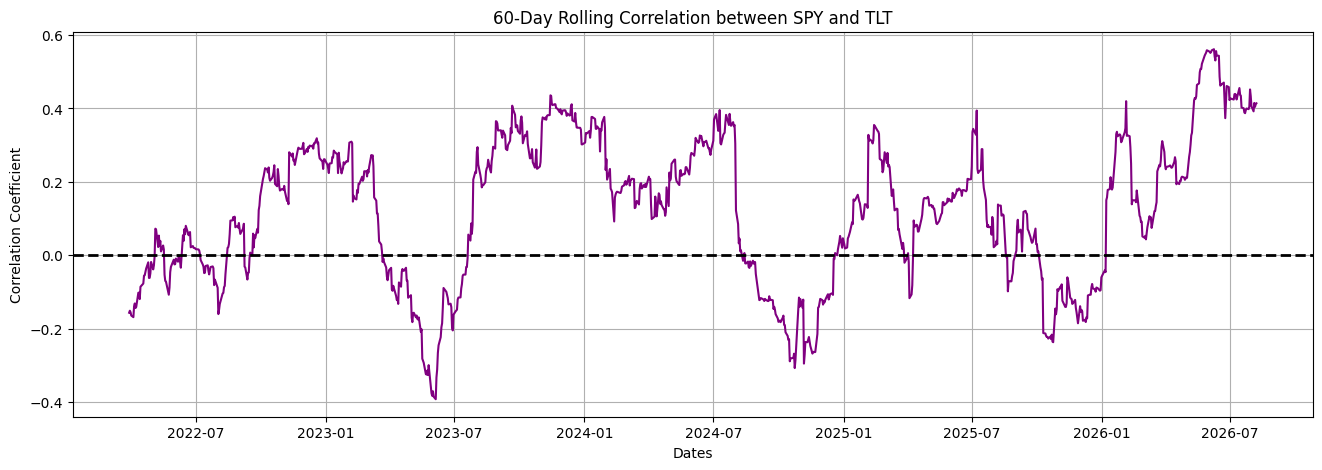

In [153]:
# 1. To calculate correlation on returns using your list pattern,
# we first compute daily percentage returns from your y7points and y8points price lists


#build up the percentage returns array
spy_returns_list = []
tlt_returns_list = []

# Loop from the second day to the end to calculate (Price_Today - Price_Yesterday) / Price_Yesterday

#compute the percentage returns
for i in range(1, len(y7points)):
    spy_ret = (y7points[i] - y7points[i-1]) / y7points[i-1]
    tlt_ret = (y8points[i] - y8points[i-1]) / y8points[i-1]
    spy_returns_list.append(spy_ret)
    tlt_returns_list.append(tlt_ret)

#build a dataframe for the returns and ensure to slice the date index [1:] because the very first day has no prior return data
returns_df = pd.DataFrame({
    "SPY_Daily_Return": spy_returns_list,
    "TLT_Daily_Return": tlt_returns_list
}, index=x7points[1:])

#Compute the 60-day rolling correlation using the series from the returns_df dataframe
returns_df["Rolling_Correlation"] = (
    returns_df["SPY_Daily_Return"]
    .rolling(window=60)
    .corr(returns_df["TLT_Daily_Return"])
)

#the high correlation dataframe contains the data where the rolling correlation > 0.5
high_corr_df = returns_df[returns_df["Rolling_Correlation"] > 0.5]

print(returns_df)


plt.figure(figsize=(16, 5))
plt.plot(returns_df.index, returns_df["Rolling_Correlation"], color="purple")
plt.axhline(y=0, color="black", linestyle="--", linewidth=2)
plt.xlabel("Dates")
plt.ylabel("Correlation Coefficient")
plt.title("60-Day Rolling Correlation between SPY and TLT")
plt.grid()
plt.show()

In [154]:


#get the SPY AND TLT series from the returns_df
spy_series = returns_df["SPY_Daily_Return"]
tlt_series = returns_df["TLT_Daily_Return"]

spy_mean = spy_series.mean()
spy_min = spy_series.min()
spy_max = spy_series.max()
spy_std = spy_series.std()

print(f"  SPY Mean : {round((spy_mean), 6)}")
print(f"  SPY Minimum : {round(spy_min, 6)} ")
print(f"  SPY Maximum :  {round(spy_max, 6)} ")
print(f"  SPY Standard:   {round(spy_std, 6)} ")

tlt_mean = tlt_series.mean()
tlt_min = tlt_series.min()
tlt_max = tlt_series.max()
tlt_std = tlt_series.std()


print(f"  TLT Mean : {round((tlt_mean), 6)}")
print(f"  TLT Minimum : {round(tlt_min, 6)} ")
print(f"  TLT Maximum :  {round(tlt_max, 6)} ")
print(f"  TLT Standard Deviation :   {round(tlt_std, 6)}")


  SPY Mean : 0.000536
  SPY Minimum : -0.058543 
  SPY Maximum :  0.105019 
  SPY Standard:   0.011042 
  TLT Mean : -0.00031
  TLT Minimum : -0.034183 
  TLT Maximum :  0.038473 
  TLT Standard Deviation :   0.009971
